![alt text](1_Q6yA_1B_vsdGWAAwB8Z7rA.webp "Title")

In [1]:
from pathlib import Path
import random, shutil
from PIL import Image

![alt text](b6337e9122efe9c56985302d3123951ddd237ee6-840x331.webp "Title")

In [2]:
random.seed(42)

In [4]:
SOURCE = Path("catsdogs/PetImages")
CAT_DIR = SOURCE/"Cat"
DOG_DIR = SOURCE/"Dog"
TARGET = Path("data")

In [7]:
for split in ["train","val","test"]:
    for cls in ["cats","dogs"]:
        (TARGET/split/cls).mkdir(parents=True, exist_o=True)

In [8]:
def list_valid_images(folder):
    paths = []
    for p in folder.iterdir():
        if p.is_file():
            try:
                with Image.open(p) as im:
                    im.verify()  # sadece doğrulama; okuma yok
                paths.append(p)
            except Exception:
                # bozuk dosya/yanlış formatı atla
                pass
    return paths

In [9]:
cats = list_valid_images(CAT_DIR)
dogs = list_valid_images(DOG_DIR)
print(f"Geçerli kedi görseli: {len(cats)}, köpek: {len(dogs)}")

C:\Users\523579\AppData\Roaming\Python\Python39\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Geçerli kedi görseli: 12499, köpek: 12499


In [10]:
def split_copy(files, cls_name):
    random.shuffle(files)
    n = len(files)
    n_train = int(0.70*n)
    n_val   = int(0.15*n)
    parts = {
        "train": files[:n_train],
        "val"  : files[n_train:n_train+n_val],
        "test" : files[n_train+n_val:]
    }
    for split, items in parts.items():
        for src in items:
            dst = TARGET/split/cls_name/src.name
            if not dst.exists():
                shutil.copy2(src, dst)

split_copy(cats, "cats")
split_copy(dogs, "dogs")

# Kontrol:
for split in ["train","val","test"]:
    n_c = len(list((TARGET/split/"cats").glob("*")))
    n_d = len(list((TARGET/split/"dogs").glob("*")))
    print(split, "-> cats:", n_c, "dogs:", n_d)

train -> cats: 8749 dogs: 8749
val -> cats: 1874 dogs: 1874
test -> cats: 1876 dogs: 1876


harika—şimdi **2) Data generator’lar (augment + rescale)** adımını “ne yapıyoruz, neden yapıyoruz” diye **çok net** anlatalım. Aşağıda hem **kod** hem de **sebepleri** var. (Klasörlerimiz: `data/train`, `data/val`, `data/test` içinde `cats/` ve `dogs/` alt klasörleri.)

---

# 2) Data generator’lar — Adım adım

## 2.1 Neden `ImageDataGenerator`?

* **Diskten akış**: Tüm görselleri RAM’e yüklemeyiz; eğitim sırasında **parti parti (batch)** okunur.
* **Anında (on-the-fly) augmentation**: Görüntüler her epoch’ta **farklı** dönüşümlerle modele verilir → **genelleme** artar, **overfitting** azalır.
* **Ölçekleme (rescale)**: Piksel değerlerini `[0, 255]` → `[0, 1]` aralığına çeker; **eğitimi stabil** yapar.

## 2.2 Neden 160×160?

* CNN’ler **sabit boyut** ister; ham resimler farklı boyutta olduğu için **tek boyuta** getiriyoruz.
* 160×160:

  * **Hız/performans dengesi** için iyi “orta yol”:

    * 128×128 → daha hızlı, biraz daha düşük doğruluk
    * 224×224 → daha iyi temsil, **daha yavaş/çok bellek**
  * Basit bir CNN için 160×160 **gayet yeterli**. (İstersen 128×128 de kullanabilirsin.)
* Not: Kareye zorlamak **oranları** bozabilir; ama hafif augment + evrişimler bunu tolere eder. (Daha ileri: `RandomCrop`, pad’leyip kırpma veya transfer learning tarafında modelin `preprocess_input`’ı.)

## 2.3 Augmentation parametreleri ne yapar?

* `rotation_range=15`: ±15° döndürür → açı değişimine dayanıklılık.
* `width_shift_range=0.10`, `height_shift_range=0.10`: %10 kaydırma → kadraj kaymalarına dayanıklılık.
* `shear_range=0.10`: ince eğme → perspektif/şekil varyasyonu.
* `zoom_range=0.10`: hafif yakınlaştır/uzaklaştır.
* `horizontal_flip=True`: yatay çevirme (kedi/kopek için mantıklı).
* **Kural**: Augment **hafif** olmalı; aşırısı **etiket gürültüsü** yaratır.

## 2.4 Neden val/test’te sadece `rescale`?

* **Değerlendirme gerçekçi** olsun istiyoruz. Validation/test’e augment uygularsan **ölçüm bozulur** (modeli zorlaştırırsın).

## 2.5 Diğer kritik ayarlar

* `class_mode='binary'`: İkili sınıflandırma → y label’ı tek sütun (0/1).
* `shuffle=True` (train): Karıştır → daha iyi öğrenme.
* `shuffle=False` (test): Confusion Matrix vb. için **sıra korunmalı**.
* `batch_size=32`: GPU belleği / hız dengesi. Küçük batch → daha gürültülü ama genelde iyi.

---

**Notlar**

* `len(train_gen)` → epoch başına adım sayısı (≈ num\_samples / batch\_size). Keras bunu otomatik kullanır.
* Reprodüksiyon için ek olarak `import numpy as np; import tensorflow as tf; np.random.seed(42); tf.random.set_seed(42)` yapabilirsin.
* CPU → `fit(..., workers=4, use_multiprocessing=True)` hızlandırabilir.

---

İstersen şimdi **3) Model** (Conv→ReLU→Pool→Dense + Dropout), **4) Eğitim**, **5) Test + CM**, **6) Tek görsel tahmini** adımlarına geçelim. Hazır mısın?


<video controls src="cnn-4.mp4" />

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE   = (160, 160)   # 128x128 de kullanılabilir
BATCH_SIZE = 32

# --- Eğitim: rescale + hafif augmentation ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True
)

# --- Doğrulama/Test: sadece rescale ---
val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    "data/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,      # eğitimde karıştır
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    "data/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False      # ölçümü sabit tut
)

test_gen = test_datagen.flow_from_directory(
    "data/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False      # CM/rapor için önemli
)

print("Sınıf indeksleri:", train_gen.class_indices)  # {'cats': 0, 'dogs': 1}
print("Train adım sayısı:", len(train_gen), "| Val:", len(val_gen), "| Test:", len(test_gen))


Found 17498 images belonging to 2 classes.
Found 3748 images belonging to 2 classes.
Found 3752 images belonging to 2 classes.
Sınıf indeksleri: {'cats': 0, 'dogs': 1}
Train adım sayısı: 547 | Val: 118 | Test: 118


harika soru! “Augmentation ayarları” neden önemli, neyi değiştiriyor ve **ne kadar** vermelisin—hepsini netleştireyim.

---

# Augmentation neden var?

**Amaç:** Eğitimde gördüğün görüntüleri küçük, “etiketi bozmayan” rastgele dönüşümlerle çeşitlendirip modelin **genelleme gücünü** artırmak ve **overfitting’i** azaltmak.

* Gerçekte aynı kedi/köpek:

  * biraz sağa kaymış olabilir (kırpılmış kadraj),
  * biraz döndürülmüş olabilir,
  * yakından/uzaktan çekilmiş olabilir,
  * ayna görüntüsü gibi olabilir.
* Augmentation, modeline “**bu değişimler olsa bile sınıf aynı**” mesajını öğretir → model **invariant** (dayanıklı) olur.

> Kısa matematik sezgisi: Eğitim hedefin “f(T(x)) = f(x)”. Yani dönüştürülmüş görüntü T(x) de aynı etikete gitmeli. Bu, **veri temelli bir regularization** gibi çalışır (dropout/l2’ye benzer etki).

---

# Her parametre tam olarak ne yapar?

(İşlev + ne kadar “hafif/sert” verdiğinde olabilecekler)

* `rotation_range=15`
  Görseli rastgele **±15°** döndürür.

  * **Hafif (10–20°)**: Doğal kamera eğimlerine karşı dayanıklılık.
  * **Aşırı (45–90°)**: Kediyi baş aşağı çevirebilir; gerçek dağılımdan uzaklaşır → **zarar**.

* `width_shift_range=0.10`, `height_shift_range=0.10`
  Genişliğin/yüksekliğin **%10’u kadar** sağa/sola/aşağı/yukarı kaydırır.

  * **Hafif (5–15%)**: Kadraj farklarını tolere eder.
  * **Aşırı (≥30%)**: Ana nesne kadraj dışına taşabilir → etikete zarar.

* `zoom_range=0.10`
  **±%10** yakınlaştır/uzaklaştır.

  * **Hafif (10–20%)**: Farklı çekim mesafelerine dayanıklılık.
  * **Aşırı (≥40%)**: Nesne çok küçük/büyük kalır → öğrenme zorlaşır.

* `shear_range=0.10`
  Hafif **eğme/şeritleme** (paralel kaydırma) etkisi; perspektif çeşitliliği kazandırır.

  * **Hafif (0.05–0.15)**: Faydalı olabilir.
  * **Aşırı**: Nesneyi yapayca deforme eder → anlamsız örnekler.

* `horizontal_flip=True`
  **Yatay ayna**. Kediler/köpekler için **mantıklı** (sağdan/ soldan bakış aynı sınıf).

  * **Dikkat**: Bazı problemler için **yasak** (örn. “6” ↔ “9” el yazısı, medikal görüntüde sağ-sol kritik).

* `rescale=1./255`
  Pikselleri 0–255’ten **0–1** aralığına çeker. **Eğitimi kararlı** ve daha hızlı yapar. (Bunu val/test’te de yaparız.)

---

# Ne kadar augmentation vermeliyim?

**Kural:** “**Hafif ama çeşitli**”. Aşırı verirsen **etiket gürültüsü** yaratırsın (yanlış öğretim).

* **Başlangıç için güvenli** (Cats vs Dogs):

  * `rotation_range=10–20`
  * `width/height_shift_range=0.05–0.15`
  * `zoom_range=0.10–0.20`
  * `shear_range=0.05–0.15`
  * `horizontal_flip=True`
* **Belirti**: Eğer **val loss artıyor, train loss düşüyorsa** (overfit) → augmenti biraz **artır** (veya dropout ↑).
  Eğer **hem train hem val zorlanıyor** → augment **fazla** gelmiş olabilir → biraz **azalt**.

---

# Neden val/test’te augmentation yok?

* Değerlendirme, **gerçek kullanıcı dağılımını** temsil etmeli.
* Val/test’e dönüşüm uygularsan ölçtüğün başarı **yapay** olarak düşebilir (ölçüm yanlılığı).
* Sadece `rescale` kalır → **temiz ölçüm**.

---

# Hangi projede hangi augment?

| Problem tipi             | Güvenli augmentler                              | Kaçınılması gerekenler               |
| ------------------------ | ----------------------------------------------- | ------------------------------------ |
| Kediler vs Köpekler      | Rot≤20°, shift≤15%, zoom≤20%, shear≤15%, H-flip | V-flip, aşırı rotasyon/kırpma        |
| Doğa/nesne sınıflandırma | Yukarıdakiler + hafif parlaklık/kontrast        | Renkleri aşırı bozma                 |
| Rakam/harf (MNIST)       | Hafif rot/shift/zoom                            | H-flip (6↔9), aşırı shear            |
| Medikal (X-ray, MRI)     | Çok kısıtlı/none; hafif normalizasyon           | Flip/rotasyon (anatomik anlam bozar) |

*(H-flip = yatay flip)*

---

# Özet cümle (cebe yaz)

> **Augmentation**, eğitimde **etiketi koruyan küçük rastgele dönüşümler** uygulayarak modelin **genellemesini** güçlendirir ve **overfitting’i** azaltır. Hafif tut; validation eğrileriyle dozunu ayarla.

---


* **Augmentation**, tek bir resmi (veya batch’teki her resmi) **eğitim anında** rastgele küçük dönüşümlerle (döndürme, kaydırma, zoom, flip…) **farklı varyasyonlara** çevirir.
* Bu dönüşümler **modelin dışında** (data pipeline’da) yapılır; **Conv/Pooling katmanları başlamadan hemen önce** uygulanır.
* Böylece **aynı orijinal görsel**, her epoch’ta **başka bir versiyonuyla** ağa girer → **etkin veri sayısı artar**, model **genelleme**yi öğrenir, **overfitting** azalır.
* Etiket **değişmez** (kedi, kedi olarak kalır). Ama dönüşümler **aşırı** olursa etiket anlamı bozulabilir (o yüzden “hafif” tutuyoruz).
* **Pooling** augmentation yapmaz; sadece Conv çıkışındaki özellik haritalarını **altörnekler** (2×2 gibi) ve konuma duyarlılığı azaltır. Yani sıra: **Augment → (Normalize/Rescale) → Conv → ReLU → Pool → …**

> Validation/Test’te augmentation uygulanmaz (sadece `rescale`), çünkü performansı **gerçek dağılımda** ölçmek isteriz.
> (İleri seviye: *Test-Time Augmentation (TTA)* ile inference’ta birkaç dönüşüm yapıp ortalama almak mümkün, ama bu ayrı bir tekniktir.)

---


![alt text](4b7a21bf063d18eff28342de11fe8ca7f0d1c0e2-1140x351.webp "Title")

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.metrics import AUC

IMG_SIZE = (160,160)

def make_cnn(input_shape=IMG_SIZE+(3,), dropout=0.5): #160x160x3
    model = models.Sequential([
        layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPool2D(2),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPool2D(2),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.MaxPool2D(2),
       # Eski:
        # layers.Flatten(),
        # layers.Dropout(0.5),
        # layers.Dense(128, activation='relu'),
        
        # Yeni:
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        #layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
        layers.Dense(64,activation="relu", kernel_initializer='he_normal'),
        layers.Dense(1, activation='sigmoid')  # binary çıktı
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy', AUC(name='auc')])
    return model

model = make_cnn()
model.summary()

early = EarlyStopping(monitor='val_auc', mode='max', patience=5,
                      restore_best_weights=True, verbose=1)
ckpt  = ModelCheckpoint("best_cnn.keras", monitor='val_auc', mode='max',
                        save_best_only=True, verbose=1)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 160, 160, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 80, 80, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 80, 80, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 40, 40, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 40, 40, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 20, 20, 128)      0

---

# Neden `input_shape=IMG_SIZE+(3,)`? (ve `[160,160,3]` farkı ne?)

* `IMG_SIZE` değişkenimiz `(160,160)`.
* `IMG_SIZE + (3,)` → Python’da **tuple birleştirme**: `(160,160,3)` olur.
* **Eşdeğerdir**: `input_shape=(160,160,3)` veya `input_shape=[160,160,3]` yazabilirdik.
* Böyle yazmamızın nedeni: **çözünürlüğü tek yerden** (IMG\_SIZE) değiştirince model otomatik uyum sağlasın.

---

# `padding='same'` ne demek? (ve neden kullandık?)

* **`valid`** (varsayılan): Kenarlarda **padding yok** → çıktı en-boy **küçülür**.
* **`same`**: Kenarlara **0 padding** ekler → stride=1 iken en-boy **değişmez** (aynı kalır).

**Neden iyi?**

* Uzamsal boyutları **çok hızlı küçültmeyiz**; kenar/pencere etkileri **daha iyi yakalanır**.
* Sonraki **MaxPool(2×2)** ile zaten kontrollü bir şekilde yarıya indiriyoruz; önce conv ile “kayıp yaşamadan” özellik çıkarmak istiyoruz.

**Kısa karşılaştırma**

| Parametre         | En-boy (stride=1) | Kenar bilgisi                              |
| ----------------- | ----------------- | ------------------------------------------ |
| `padding='valid'` | Küçülür           | Kenarlar daha erken “törpülenir”           |
| `padding='same'`  | Sabit kalır       | Kenar/çerçeve özellikleri daha iyi korunur |

---

# Conv/Pool/Dense katmanları – ne yapıyor & şekiller nasıl değişiyor?

Modelimiz (özet):

```
Conv2D(32, 3x3, same) → MaxPool(2x2)
Conv2D(64, 3x3, same) → MaxPool(2x2)
Conv2D(128,3x3, same) → MaxPool(2x2)
Flatten → Dropout(0.5) → Dense(128, relu) → Dense(1, sigmoid)
```

**Girdi şekli:** `(160,160,3)`

Aşağıdaki **tüm Conv’larda stride=1** kabulüyle:

1. **Conv2D(32, 3×3, same)**:

   * Çıktı: `(160,160,32)` → 32 adet “özellik haritası”.
   * **Neden 3×3?** Küçük çekirdek; parametre az, performans iyi bir standart.

2. **MaxPool(2×2)**:

   * Çıktı: `(80,80,32)` → en-boy **yarıya** iner.
   * **Neden?** Hesap yükünü azaltır, küçük kaymaların etkisine dayanıklılık kazandırır.

3. **Conv2D(64, 3×3, same)** → `(80,80,64)`

4. **MaxPool(2×2)** → `(40,40,64)`

5. **Conv2D(128, 3×3, same)** → `(40,40,128)`

6. **MaxPool(2×2)** → `(20,20,128)`

7. **Flatten** → `20*20*128 = 51,200` özellik (1D vektör)

8. **Dropout(0.5)** → Eğitimde bu vektörün **%50’sini rastgele kapatır** (overfitting’i azaltır)

9. **Dense(128, relu)**: Tam bağlı katman, **soyut** özellik kombinasyonları öğrenir

10. **Dense(1, sigmoid)**: Çıkış **olasılık** (0–1), **ikili sınıflandırma** için

> **Parametre sayısı notu:**
> Flatten sonrası **51,200 → 128** bağlantı ≈ **6.55 milyon** ağırlık yapar (51,200×128).
> Bu, küçük veri için büyük olabilir. İstersen:
>
> * **GlobalAveragePooling2D** kullan: `(20,20,128)` → `(128)`, sonra Dense(128) → parametreler **dramatik** düşer.
> * Veya Dense boyutunu 64’e indir, Dropout’u 0.5–0.6 tut.

---

# Aktivasyon, optimizasyon ve loss neden böyle?

* **ReLU** (gizli katmanlar): Hızlı, doygunluğa girmez (vanishing gradient’e dayanıklı).
* **Sigmoid** (çıktı): İkili problem → olasılık üretir.
* **Loss = binary\_crossentropy**: Sigmoid’le doğal çift.
* **Optimizer = Adam**: Öğrenme oranını adaptif ayarlar; görüntü işte güçlü bir varsayılan.

**Ek öneri (opsiyonel):**

* **BatchNormalization** (Conv → BN → ReLU) eklemek öğrenmeyi **stabil** ve genelde **hızlı** yapar.

---

# Early & CKPT (neden var, ne yapıyor?)

* **EarlyStopping** (`early`):

  * `monitor='val_auc'`, `mode='max'`, `patience=5`
  * **Anlamı:** **Doğrulama AUC**’u 5 epoch boyunca **iyileşmezse** eğitimi **erken durdur**.
  * `restore_best_weights=True`: En iyi AUC görülen epoch’un **ağırlıklarına geri dön**.
  * **Fayda:** **Overfitting’i** engeller, **zaman** kazandırır.

* **ModelCheckpoint** (`ckpt`):

  * `save_best_only=True`, `monitor='val_auc'`
  * **Anlamı:** Doğrulama AUC’su en yüksek olduğunda modeli **diske kaydet** (ör. `best_cnn.keras`).
  * **Fayda:** Eğitimi sonlandırdıktan sonra bile **en iyi modeli** elinde tutarsın; tekrar eğitime gerek kalmaz.

> Neden **AUC** izliyoruz?
>
> * Cats vs Dogs genelde dengeli ama AUC, **ayrıştırma gücünü** daha iyi temsil eder.
> * İstersen `monitor='val_accuracy'` da kullanabilirsin; AUC, özellikle dengesiz veri senaryolarında daha anlamlı.

---

# Kısa “neden bu mimari?” özeti

* **3 konv bloğu**: Kademeli olarak **daha fazla filtre** (32→64→128), **daha düşük çözünürlük** (160→80→40→20).
* **‘same’ padding**: Conv sonrası boyutları koru, **havuzlamayla** yarıya indir (kontrollü küçülme).
* **Dropout**: Fully-connected bölümde **genelleme**yi artır.
* **Sigmoid + BCE**: İkili sınıflandırma için standart, **olasılık** üret.
* **Early+CKPT**: **Overfit’i yakala**, **en iyi** modeli sakla.

---


In [9]:
# (opsiyonel) tekrarlanabilirlik için seed
import numpy as np, tensorflow as tf, random
np.random.seed(42); tf.random.set_seed(42); random.seed(42)

EPOCHS = 30  # EarlyStopping varsa 30-50 arası güvenli başlangıç

history = model.fit(
    train_gen,                   # eğitim verisi (augment + rescale)
    validation_data=val_gen,     # doğrulama verisi (sadece rescale)
    epochs=EPOCHS,
    callbacks=[early, ckpt],     # val_auc'ye göre en iyi ağırlıkları korur
    verbose=1,
    # workers=4, use_multiprocessing=True,   # CPU'da hız için açabilirsin
)


Epoch 1/30
322/547 [================>.............] - ETA: 1:34 - loss: 0.6850 - accuracy: 0.5473 - auc: 0.5687 

C:\Users\523579\AppData\Roaming\Python\Python39\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


547/547 [==============================] - ETA: 0s - loss: 0.6760 - accuracy: 0.5665 - auc: 0.5961  
Epoch 1: val_auc improved from -inf to 0.66868, saving model to best_cnn.keras
547/547 [==============================] - 246s 447ms/step - loss: 0.6760 - accuracy: 0.5665 - auc: 0.5961 - val_loss: 0.6429 - val_accuracy: 0.6219 - val_auc: 0.6687
Epoch 2/30
547/547 [==============================] - ETA: 0s - loss: 0.6416 - accuracy: 0.6268 - auc: 0.6758  
Epoch 2: val_auc improved from 0.66868 to 0.73323, saving model to best_cnn.keras
547/547 [==============================] - 235s 428ms/step - loss: 0.6416 - accuracy: 0.6268 - auc: 0.6758 - val_loss: 0.6139 - val_accuracy: 0.6649 - val_auc: 0.7332
Epoch 3/30
547/547 [==============================] - ETA: 0s - loss: 0.6065 - accuracy: 0.6679 - auc: 0.7286  
Epoch 3: val_auc improved from 0.73323 to 0.78992, saving model to best_cnn.keras
547/547 [==============================] - 239s 437ms/step - loss: 0.6065 - accuracy: 0.6679 - auc

Sonuçların hızlı okuması (ne anlatıyor?)

Yakınsama sağlıklı: loss ↓, val AUC 0.67 → 0.959’a kadar düzenli arttı. EarlyStopping tetiklenmedi çünkü val_auc iyileşmeye devam etti; en iyi ağırlık best_cnn.keras olarak kaydedildi (en iyi epoch ≈ 29).

Genelleme iyi: train acc ~0.869, val acc ~0.890. Aradaki fark küçük ⇒ augment faydalı.

Uyarı (Truncated File Read): veri setinde bozuk görseller var. Eğitim devam edebilmiş ama bunları temizlemek iyi olur (aşağıya komut bırakıyorum).

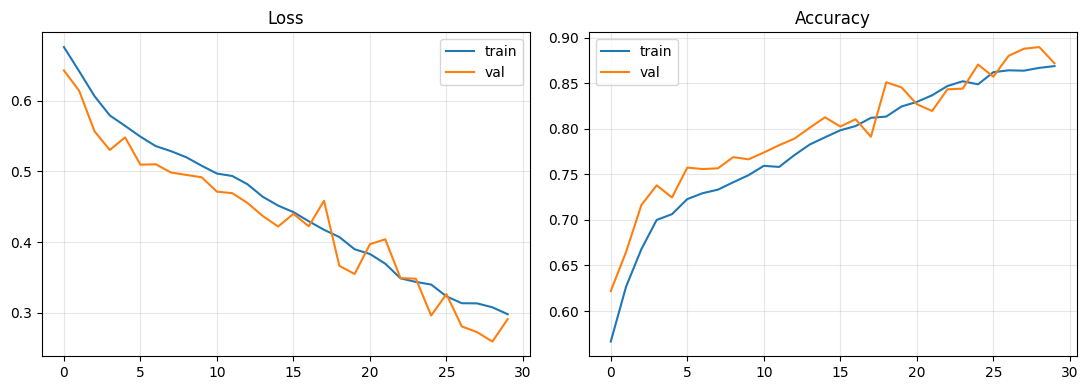

In [10]:
import matplotlib.pyplot as plt
hist = history.history

plt.figure(figsize=(11,4))
# Loss
plt.subplot(1,2,1)
plt.plot(hist['loss'], label='train')
plt.plot(hist['val_loss'], label='val')
plt.title('Loss'); plt.legend(); plt.grid(alpha=0.3)

# Accuracy
plt.subplot(1,2,2)
plt.plot(hist['accuracy'], label='train')
plt.plot(hist['val_accuracy'], label='val')
plt.title('Accuracy'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Genel test metrikleri
test_metrics = model.evaluate(test_gen, verbose=0)
print(f"Test -> Loss: {test_metrics[0]:.4f} | Acc: {test_metrics[1]:.4f} | AUC: {test_metrics[2]:.4f}")

# CM/rapor
probs = model.predict(test_gen).ravel()
y_pred = (probs >= 0.5).astype(int)
y_true = test_gen.classes

print("\nClassification report:\n", classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))
print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))


Test -> Loss: 0.2965 | Acc: 0.8803 | AUC: 0.9465
118/118 [==============================] - 15s 123ms/step

Classification report:
               precision    recall  f1-score   support

        cats       0.89      0.87      0.88      1876
        dogs       0.87      0.89      0.88      1876

    accuracy                           0.88      3752
   macro avg       0.88      0.88      0.88      3752
weighted avg       0.88      0.88      0.88      3752

Confusion matrix:
 [[1634  242]
 [ 207 1669]]


TEST -> Loss: 0.2686 | Acc: 0.8915 | AUC: 0.9562
118/118 [==============================] - 13s 112ms/step

Classification report:
               precision    recall  f1-score   support

        cats       0.89      0.90      0.89      1876
        dogs       0.90      0.89      0.89      1876

    accuracy                           0.89      3752
   macro avg       0.89      0.89      0.89      3752
weighted avg       0.89      0.89      0.89      3752

Confusion matrix:
 [[1681  195]
 [ 212 1664]]


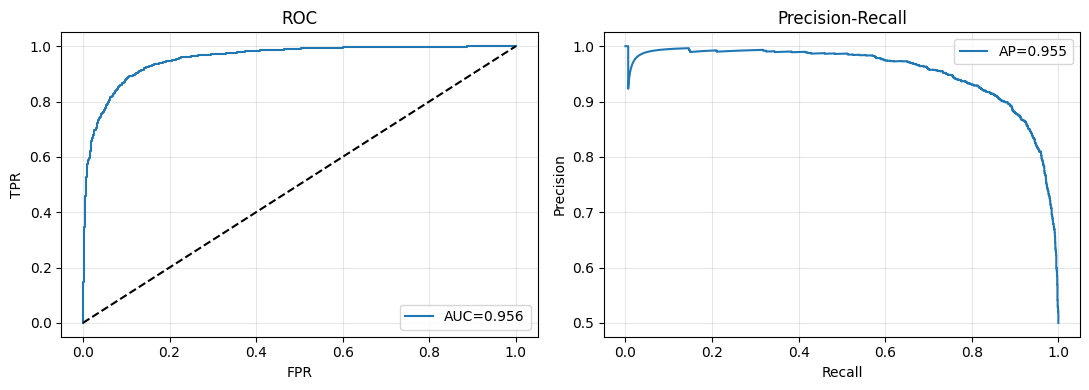

In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

# 1) En iyi modeli yükle (garanti)
best_model = tf.keras.models.load_model("best_cnn.keras")

# 2) Test metri̇kleri
test_loss, test_acc, test_auc = best_model.evaluate(test_gen, verbose=0)
print(f"TEST -> Loss: {test_loss:.4f} | Acc: {test_acc:.4f} | AUC: {test_auc:.4f}")

# 3) Olasılık ve sınıf tahminleri
probs = best_model.predict(test_gen).ravel()
y_pred = (probs >= 0.5).astype(int)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# 4) Rapor & CM
print("\nClassification report:\n", classification_report(y_true, y_pred, target_names=class_names))
print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))

# 5) ROC & PR eğrileri
fpr, tpr, _ = roc_curve(y_true, probs)
ap = average_precision_score(y_true, probs)

plt.figure(figsize=(11,4))
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_true, probs):.3f}")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend(); plt.grid(alpha=0.3)

prec, rec, _ = precision_recall_curve(y_true, probs)
plt.subplot(1,2,2)
plt.plot(rec, prec, label=f"AP={ap:.3f}")
plt.title("Precision-Recall"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [27]:
from tensorflow.keras.preprocessing import image

idx_to_cls = {v:k for k,v in train_gen.class_indices.items()}  # {0:'cats',1:'dogs'}

def predict_one(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    arr = image.img_to_array(img)/255.0
    arr = np.expand_dims(arr, axis=0)  # (1,H,W,3)
    p = float(model.predict(arr)[0][0])
    pred = idx_to_cls[1] if p>=0.5 else idx_to_cls[0]
    print(f"Prediction: {pred}  |  prob(class '1'={idx_to_cls[1]}) = {p:.3f}")

# Örnek:
predict_one("data/test/cats/365.jpg")
# predict_one("PetImages/Dog/1.jpg")


1/1 [==============================] - 0s 38ms/step
Prediction: cats  |  prob(class '1'=dogs) = 0.176


118/118 [==============================] - 13s 111ms/step


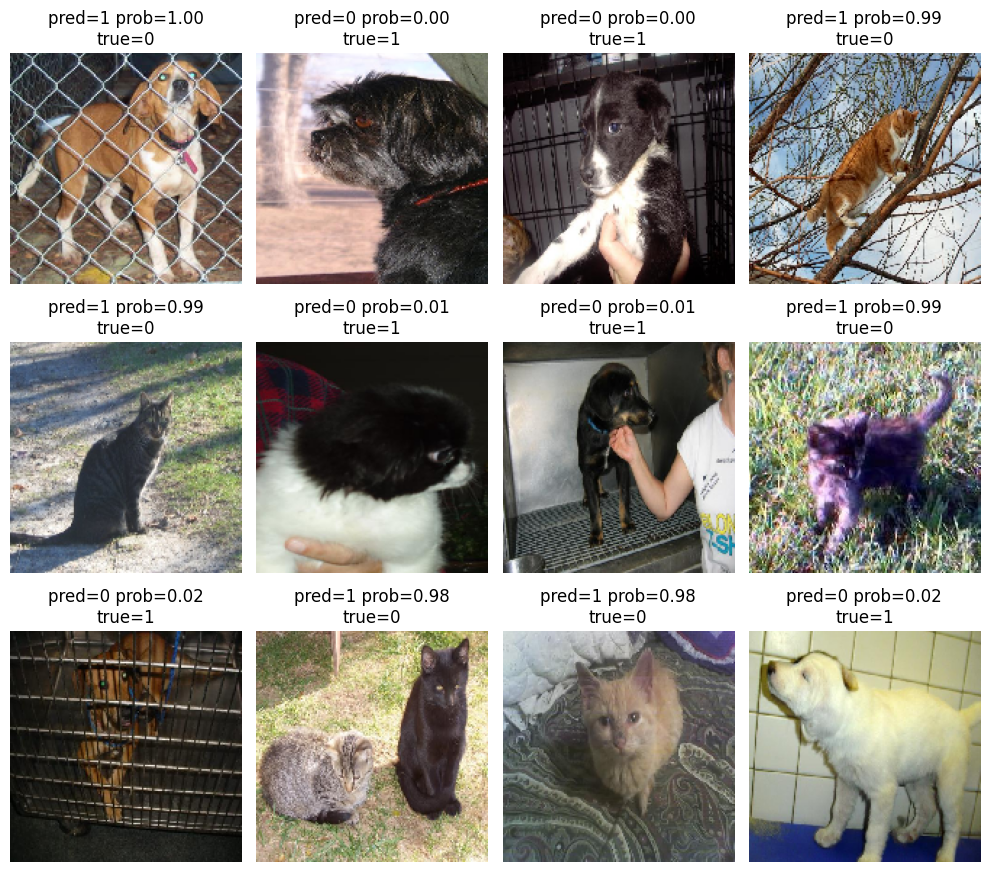

In [28]:
import numpy as np, matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

filenames = test_gen.filenames
probs = best_model.predict(test_gen).ravel()
y_pred = (probs >= 0.5).astype(int)
y_true = test_gen.classes

# Yanlışlar:
wrong_idx = np.where(y_pred != y_true)[0]
# "Köpek" olasılığını p kabul ediyoruz (class_indices{'cats':0,'dogs':1})
conf = np.abs(probs[wrong_idx] - 0.5)  # 0.5'ten uzaklık = özgüven
top = wrong_idx[np.argsort(-conf)[:12]]  # en "özgüvenli" yanlışlar

plt.figure(figsize=(10,9))
for i, idx in enumerate(top, 1):
    img_path = test_gen.directory + "/" + filenames[idx]
    img = image.load_img(img_path, target_size=test_gen.target_size)
    plt.subplot(3,4,i); plt.imshow(img); plt.axis("off")
    plt.title(f"pred={y_pred[idx]} prob={probs[idx]:.2f}\ntrue={y_true[idx]}")
plt.tight_layout(); plt.show()


harika skorlar! (Acc ≈ **0.892**, AUC ≈ **0.956**). CM de dengeli:

* Cats: TP=1681, FN=195
* Dogs: TP=1664, FN=212
  Hatalar sınıflar arasında **simetrik**; bu iyi bir genelleme işareti.

## “Parametreleri düşürmeseydik loss daha da düşer miydi?”

* **Eğitim (train) loss’u:** Daha **büyük** model çoğu zaman **daha fazla kapasite** ⇒ **train loss daha hızlı ve daha aşağı** iner.
* **Doğrulama/Test loss’u:** Aynı şey **garanti değil**. Büyük model:

  * **Daha fazla ezber** (overfitting) yapabilir ⇒ **val/test loss artabilir**, accuracy/AUC aynı kalabilir hatta düşebilir.
  * **Aşırı özgüvenli** tahminler üretir: birkaç hatayı **çok yüksek olasılıkla** yanlış söylerse **cross-entropy** onları ağır cezalandırır ⇒ **loss yüksek** olabilir, accuracy değişmese bile.
* **Özet:** “Parametre ↑ ⇒ train loss ↓” neredeyse kesin; ama “test loss ↓” **garanti değil**. Hedefimiz **val/test metrikleri** (özellikle AUC/acc). Senin AUC 0.956 zaten güçlü.

## Neden bazı kedileri köpek dedi?

* Veri gürültüsü: PetImages’ta **bozuk/etiketsiz/karışık** görseller var (log’da `Truncated File Read` uyarısı geldi).
* Görsel içeriği: Karanlık, uzaktan, hareketli kadraj vs.
* Model davranışı: **sınırda** olasılıklar (0.4–0.6 bandı) yanlış tarafa düşmüş olabilir.

## Hızlı teşhis: “yanlışları” gör

Aşağıyla en güvenle **yanlış** sınıflananları (en büyük olasılıkla yanlış) görüp data/augment iyileştirmesi düşünebilirsin:

```python
import numpy as np, matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

filenames = test_gen.filenames
probs = best_model.predict(test_gen).ravel()
y_pred = (probs >= 0.5).astype(int)
y_true = test_gen.classes

# Yanlışlar:
wrong_idx = np.where(y_pred != y_true)[0]
# "Köpek" olasılığını p kabul ediyoruz (class_indices{'cats':0,'dogs':1})
conf = np.abs(probs[wrong_idx] - 0.5)  # 0.5'ten uzaklık = özgüven
top = wrong_idx[np.argsort(-conf)[:12]]  # en "özgüvenli" yanlışlar

plt.figure(figsize=(10,9))
for i, idx in enumerate(top, 1):
    img_path = test_gen.directory + "/" + filenames[idx]
    img = image.load_img(img_path, target_size=test_gen.target_size)
    plt.subplot(3,4,i); plt.imshow(img); plt.axis("off")
    plt.title(f"pred={y_pred[idx]} prob={probs[idx]:.2f}\ntrue={y_true[idx]}")
plt.tight_layout(); plt.show()
```

Bu grid sana **hangi motiflerde** yanıldığını gösterecek (bulanık, kesik, sıra dışı poz vs.).

## “Loss’u düşürmek ve doğruluğu artırmak” için net öneriler (öncelik sırasıyla)

1. **Veri temizliği (kolay kazanç)**

   * Bozuk görselleri sil (özellikle PetImages): daha önce paylaştığım `PIL.Image.verify()` betiğini **train/val/test** üzerinde koştur.

2. **Eşik ayarı (hata dengesiyle oyna)**

   * Dataset dengeli; 0.5 genelde iyi. Yine de **maksimum accuracy** veya **maksimum F1** için eşiği ayarlayabilirsin:

   ```python
   import numpy as np
   ts = np.linspace(0.3, 0.7, 41)
   best_acc, best_t = 0, 0.5
   for t in ts:
       yp = (probs >= t).astype(int)
       acc = (yp==y_true).mean()
       if acc > best_acc: best_acc, best_t = acc, t
   print(f"Best accuracy @ threshold={best_t:.2f}: {best_acc:.4f}")
   ```

   * Kediler “köpek” deniyorsa eşiği **biraz ↑** (örn. 0.52–0.55) deneyip hataları dengele.

3. **GAP kullan (parametreyi düşür, test loss/acc’i iyileştir)**

   * Flatten→Dense(128) ≈ **6.5M** parametre. **GlobalAveragePooling2D** ile **\~60×** az parametre, daha iyi genelleme:

   ```python
   layers.GlobalAveragePooling2D(),
   layers.Dropout(0.3),
   layers.Dense(128, activation='relu', kernel_initializer='he_normal')
   ```

   Pratikte test loss genelde **düşer**, acc/AUC **aynı veya daha iyi** olur.

4. **Girdi boyutu ↑ (hesabın varsa)**

   * 160→**192** veya **224**: nesne detayını daha iyi yakalar → acc/AUC artabilir.
   * GPU yoksa batch’i düşür (16); eğitim süresi artar.

5. **Augment’i veri odaklı ayarla**

   * Kediler/köpekler için **RandomBrightness/Contrast** küçük aralıklar eklemek faydalı olur (ışık değişimleri).
   * Aşırı dönüşümden kaçın (etiket gürültüsü üretme).
   * Keras preprocessing layers alternatifi:

     ```python
     data_augment = tf.keras.Sequential([
         layers.RandomFlip("horizontal"),
         layers.RandomRotation(0.05),
         layers.RandomZoom(0.1),
         layers.RandomContrast(0.1),
     ])
     ```

     (Modelin başına koyarsın; `ImageDataGenerator` yerine/yanına da kullanılabilir.)

6. **Düzenlileştirme (regularization)**

   * **Dropout** 0.5→0.6 veya **L2 weight decay** (`kernel_regularizer=tf.keras.regularizers.l2(1e-4)`) Dense/Conv’lara.
   * **Label smoothing** (aşırı özgüveni azaltır):
     `loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05)`

7. **Transfer Learning (en hızlı büyük sıçrama)**

   * `MobileNetV2` / `EfficientNetB0` (ImageNet ön-eğitimli): 5–10 epoch’ta **%93–95+** acc görmek kolay.

   ```python
   base = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(160,160,3))
   base.trainable = False
   inputs = layers.Input((160,160,3))
   x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
   x = base(x, training=False)
   x = layers.GlobalAveragePooling2D()(x)
   x = layers.Dropout(0.2)(x)
   outputs = layers.Dense(1, activation='sigmoid')(x)
   tl_model = tf.keras.Model(inputs, outputs)
   tl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
   ```

   * Sonra son blokları **düşük LR** ile **fine-tune**.

### Neyi beklemelisin?

* **Parametreyi artırmak** (Flatten ile büyük Dense): Train loss ↓ (kesin); Test loss/acc **aynı kalabilir veya kötüleşebilir**.
* **Parametreyi akıllıca azaltmak** (GAP, BN, uygun augment): Test loss/acc **iyileşme** eğiliminde.
* **Transfer learning**: En hızlı ve büyük kazanç.

İstersen 12–16 görsellik “en güvenli yanlışlar” gridini gönder; hata motiflerini birlikte okuyup augment/temizlik önerisini nokta atışı yapalım.
